In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Загрузка данных

In [2]:
# %%capture
# !wget https://www.dropbox.com/s/64ol9q9ssggz6f1/data_ford_price.xlsx

In [3]:
ford_price_data = pd.read_excel('Data/data_ford_price.xlsx')

#  Отбор признаков: мотивация

# Предобработка данных

In [4]:
data = ford_price_data[['price','year', 'cylinders', 'odometer', 'lat', 'long', 'weather']]
data.dropna(inplace = True)

X = data.drop(columns='price')
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

/var/folders/0g/dcvscgwn2bx5ldpwsnftw38c0000gn/T/ipykernel_67206/2902426975.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace = True)


# Обучение модели

In [5]:
model = LinearRegression()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
 
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

MAE: 4682.957


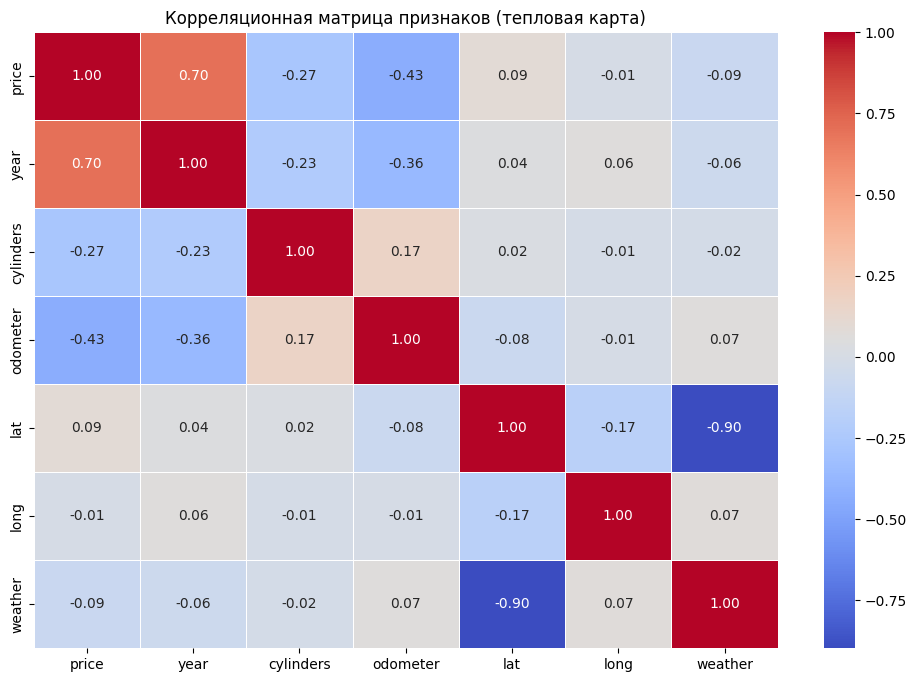

In [6]:
# Строим корреляционную матрицу
corr_matrix = data.corr(numeric_only=True)

# Строим тепловую карту
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Корреляционная матрица признаков (тепловая карта)')
plt.show()

Мы выяснили, что у нас присутствует сильная зависимость между lat и weather. Удалим lat, так как этот признак, в отличие от weather, необходимо округлять.

# Удаление избыточного признака

In [7]:
X.drop('lat', axis = 1, inplace = True)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)
y_predicted = model.predict(X_test)
 
mae = mean_absolute_error(y_test, y_predicted)
print('MAE: %.3f' % mae)

MAE: 4672.930


#  Отбор признаков: классификация методов

Методы отбора признаков предназначены для уменьшения количества входных переменных до тех значений, которые наиболее полезны для предсказательной способности модели.

<img src='Images/ml_06.png'>

# Метод рекурсивного исключения признаков (RFE)

__Метод рекурсивного исключения признаков (RFE)__ предполагает выбор признаков путём рекурсивного рассмотрения всё меньших и меньших наборов фичей.

Сначала RFE обучается на изначальной выборке и происходит оценка важности каждого признака. Затем наименее важные фичи удаляются. Эта процедура рекурсивно повторяется на сокращённом наборе до тех пор, пока в конечном итоге не будет достигнуто желаемое количество признаков в выборке.

In [10]:
from sklearn.feature_selection import RFE

In [11]:
X = data.drop(columns='price')
y = data['price']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=40)

In [13]:
# Импортируем модель линейной регрессии, которая будет использоваться в качестве оценщика (estimator)
estimator = LinearRegression()

# Инициализируем рекурсивное исключение признаков (RFE):
# - estimator: модель, по которой оценивается важность признаков
# - n_features_to_select=3: хотим оставить только 3 признака
# - step=1: удаляем по одному признаку за итерацию
selector = RFE(estimator, n_features_to_select=3, step=1)

# Обучаем RFE на обучающих данных
# Во время обучения RFE будет поочерёдно исключать наименее значимые признаки
selector = selector.fit(X_train, y_train)

# Получаем имена выбранных признаков (если X_train — DataFrame с именами колонок)
selector.get_feature_names_out()

array(['year', 'cylinders', 'lat'], dtype=object)

Также узнаем, как RFE проранжировал все доступные признаки:

In [14]:
X_train.columns

Index(['year', 'cylinders', 'odometer', 'lat', 'long', 'weather'], dtype='object')

In [15]:
selector.ranking_

array([1, 1, 4, 1, 3, 2])

#  МЕТОДЫ ВЫБОРА ПРИЗНАКОВ НА ОСНОВЕ ФИЛЬТРОВ

В качестве фильтров для выбора признаков используются уже известные статистики, такие как коэффициент корреляции Пирсона, ANOVA и т.д. При этом выбор статистических показателей сильно зависит от типов переменных в данных.

Чем больше известно о типе данных, тем проще выбрать подходящую статистическую меру для метода отбора признаков на основе фильтра. Ниже приведена схема — помощник в выборе метода селекции признаков:

<img src='Images/ml_07.png'>

Библиотека sklearn обеспечивает реализацию большинства полезных статистических показателей, например:

* коэффициента корреляции Пирсона: f_regression();
* дисперсионного анализа ANOVA: f_classif();
* хи-квадрата: chi2();
* взаимной информации: mutual_info_classif() и mutual_info_regression().

Кроме того, библиотека SciPy обеспечивает реализацию многих других статистических данных, таких как тау Кендалла (kendalltau) и ранговая корреляция Спирмена (spearmanr).

sklearn также предоставляет множество различных методов фильтрации после расчёта статистики для каждой входной переменной с целевой.

Два наиболее популярных метода:

* выбор k лучших переменных: SelectKBest;
* выбор переменных верхнего процентиля: SelectPercentile.

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression

In [19]:
# Импортируем селектор признаков, использующий тест F для регрессии
selector = SelectKBest(f_regression, k=3)  # Выбираем 3 признака с наибольшей F-статистикой

# Обучаем селектор на тренировочных данных
selector.fit(X_train, y_train)  # X_train — признаки, y_train — целевая переменная

# Вывод наиболее важных признаков 
selector.get_feature_names_out()

array(['year', 'cylinders', 'odometer'], dtype=object)

In [22]:
# Нет .ranking_, но можно посмотреть .scores_
scores = pd.Series(selector.scores_, index=X_train.columns)
print(scores.sort_values(ascending=False))  # показывает важность

year         4179.819702
odometer      979.316651
cylinders     317.305166
lat            33.803150
weather        31.784856
long            2.088583
dtype: float64
